# Text-to-Cypher Dataset Analysis
## Technical Dataset COMPLETION - Category Breakdown

This notebook provides a comprehensive analysis of the evaluation dataset before running the full Text-to-Cypher pipeline evaluation.


In [2]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Load Dataset


In [3]:
# Load the dataset
csv_path = Path('../dataset/technical_dataset_COMPLETION.csv')
df = pd.read_csv(csv_path)

print(f"Total questions in dataset: {len(df)}")
print(f"\nDataset columns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()


Total questions in dataset: 388

Dataset columns: ['Category', 'NaturalLanguageQuestion', 'CypherQuery', 'generated_question', 'ExpectedNodeLabels', 'ExpectedRelationshipTypes', 'ExpectedProperties', 'Hops', 'ExtractedPropertyValues']

First few rows:


,Category,NaturalLanguageQuestion,CypherQuery,generated_question,ExpectedNodeLabels,ExpectedRelationshipTypes,ExpectedProperties,Hops,ExtractedPropertyValues
0,Node Lookup Queries,Pull the record for CVE-2021-44228.,MATCH (c:UcoCVE {label: 'CVE-2021-44228'}) RET...,What are the full details for 'CVE-2021-44228'?,"[""UcoCVE""]",[],"[""label""]",0,"[""CVE-2021-44228""]"
1,Node Lookup Queries,Get the name and description for CWE-89.,MATCH (c:UcoCWE {ucocweID: 'CWE-89'}) RETURN c...,What is the name and description for weakness ...,"[""UcoCWE""]",[],"[""ucocweID"", ""ucocweName"", ""ucodescription""]",0,"[""CWE-89""]"
2,Node Lookup Queries,Show me all data on the 'SolarWinds Orion' cam...,MATCH (c:UcoexCAMPAIGNS {ucoexNAME: 'SolarWind...,Show me all information on the 'SolarWinds Ori...,"[""UcoexCAMPAIGNS""]",[],"[""ucoexNAME""]",0,"[""SolarWinds Orion""]"
3,Node Lookup Queries,What's the description and domain for the 'Phi...,MATCH (t:UcoexMITREATTACK {ucoexNAME: 'Phishin...,What's the description and domain for the 'Phi...,"[""UcoexMITREATTACK""]",[],"[""ucoexDESCRIPTION"", ""ucoexDOMAIN"", ""ucoexNAME""]",0,"[""Phishing""]"
4,Node Lookup Queries,Pull the entry for the 'Mimikatz' tool.,MATCH (s:UcoexSOFTWARE {ucoexNAME: 'Mimikatz'}...,Find all data for the software 'Mimikatz'.,"[""UcoexSOFTWARE""]",[],"[""ucoexNAME""]",0,"[""Mimikatz""]"


In [4]:
# Count questions per category
category_counts = df['Category'].value_counts()
print("Questions per Category:")
print("=" * 80)
for cat, count in category_counts.items():
    pct = (count / len(df)) * 100
    print(f"{cat:50s} : {count:3d} ({pct:5.1f}%)")

print(f"\nTotal categories: {len(category_counts)}")


Questions per Category:
Node Lookup Queries                                : 173 ( 44.6%)
Relationship Traversal Queries                     :  42 ( 10.8%)
Existence and Set Operations Queries               :  26 (  6.7%)
Multi-hop Queries                                  :  25 (  6.4%)
Aggregation and Counting                           :  25 (  6.4%)
Path Queries (Variable-length)                     :  25 (  6.4%)
Graph Pattern Matching                             :  25 (  6.4%)
Conditional and Boolean Queries                    :  24 (  6.2%)
Comparative and Ranking                            :  23 (  5.9%)

Total categories: 9


## 3. Visualizations


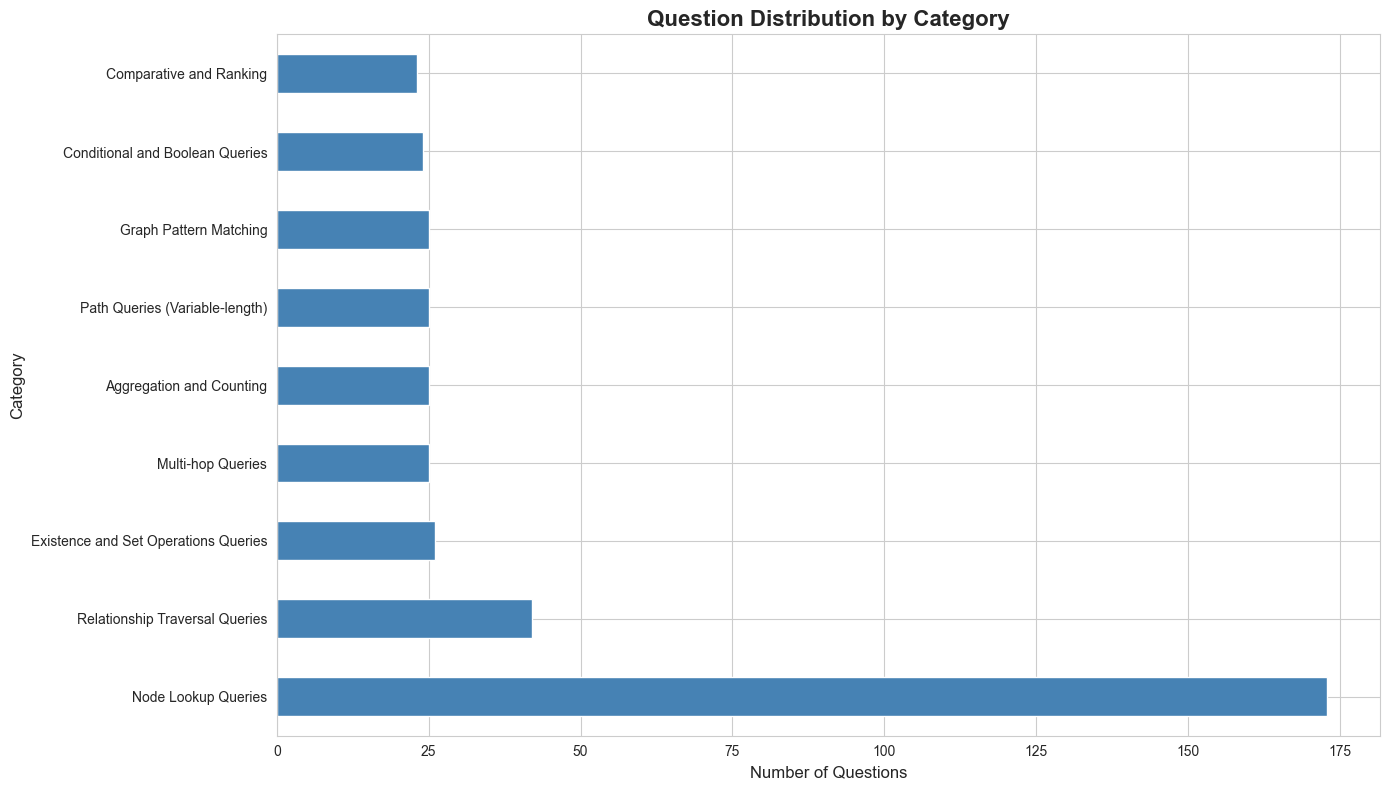

In [5]:
# Bar chart of category distribution
plt.figure(figsize=(14, 8))
category_counts.plot(kind='barh', color='steelblue')
plt.title('Question Distribution by Category', fontsize=16, fontweight='bold')
plt.xlabel('Number of Questions', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()


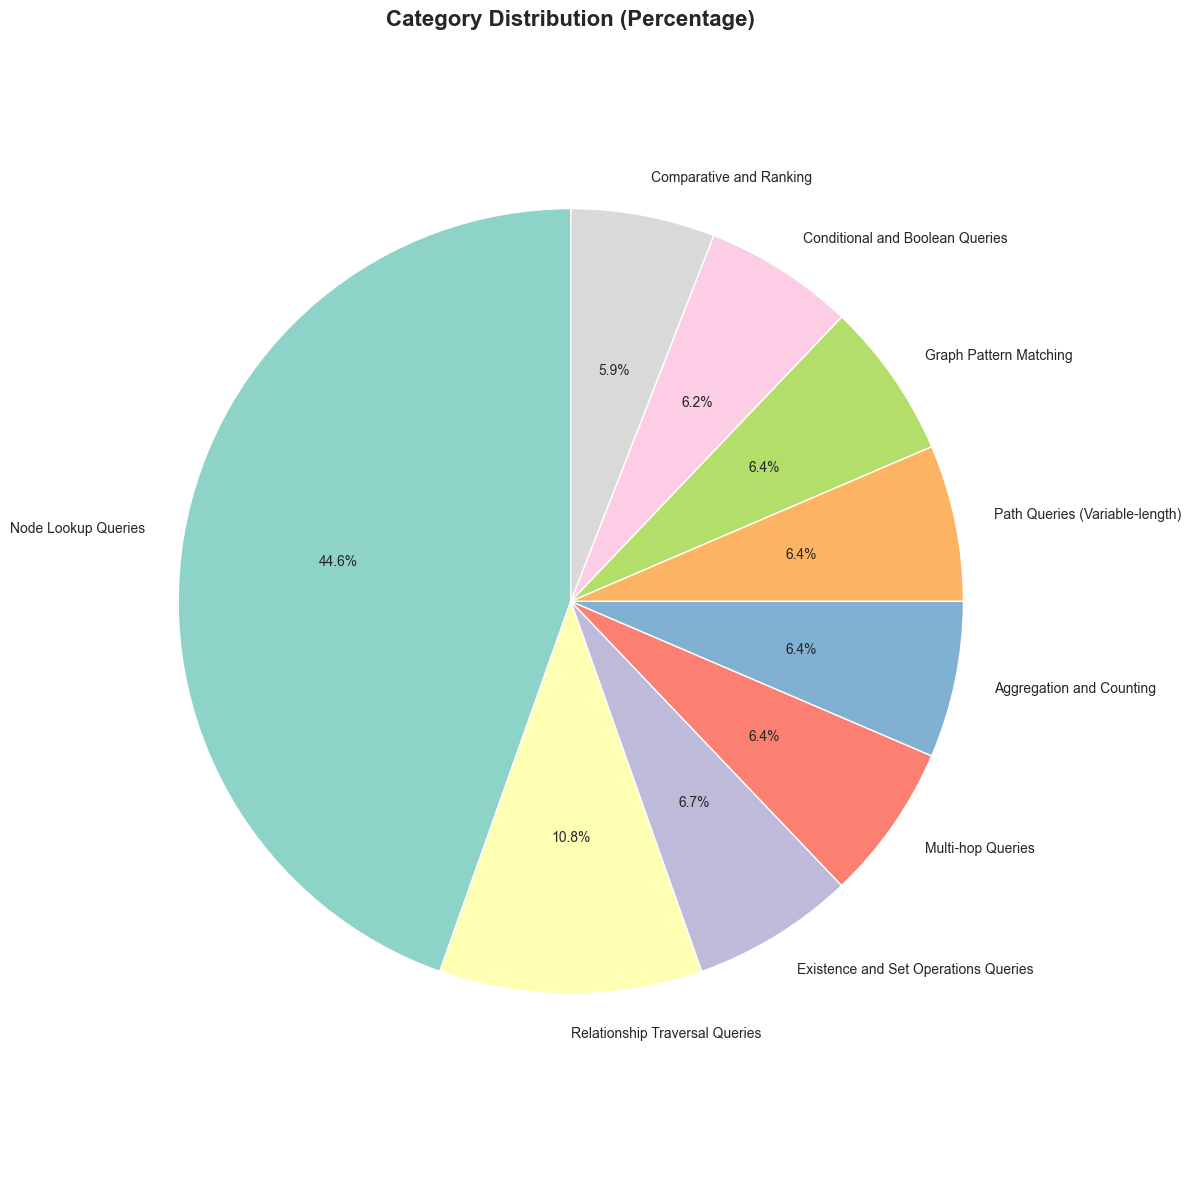

In [7]:
# Show sample questions from each category
categories = sorted(df['Category'].unique())

for cat in categories:
    print("=" * 100)
    print(f"CATEGORY: {cat}")
    print("=" * 100)
    
    cat_df = df[df['Category'] == cat]
    print(f"Total questions: {len(cat_df)}\n")
    
    # Show first 3 examples
    for idx, row in cat_df.head(3).iterrows():
        print(f"Example {idx + 1}:")
        print(f"  Question: {row['NaturalLanguageQuestion']}")
        cypher = row['CypherQuery']
        print(f"  Cypher:   {cypher[:100]}..." if len(cypher) > 100 else f"  Cypher:   {cypher}")
        print()


CATEGORY: Aggregation and Counting
Total questions: 25

Example 31:
  Question: Count the number of distinct TTPs linked to APT28.
  Cypher:   MATCH (g:UcoexGROUPS {ucoexNAME: 'APT28'})-[:UCOEXGROUPUSESTECHNIQUE]->(t:UcoexMITREATTACK) RETURN c...

Example 32:
  Question: Show a count of campaigns for each threat actor.
  Cypher:   MATCH (g:UcoexGROUPS)<-[:UCOEXATTRIBUTEDTO]-(c:UcoexCAMPAIGNS) RETURN g.ucoexNAME, count(c) AS campa...

Example 33:
  Question: Calculate the average exploitability score across all CVEs.
  Cypher:   MATCH (c:UcoCVE) RETURN avg(toInteger(c.ucoexploitabilityScore))

CATEGORY: Comparative and Ranking
Total questions: 23

Example 70:
  Question: Show me CVEs where the exploitability score is greater than the impact score.
  Cypher:   MATCH (c:UcoCVE) WHERE toInteger(c.ucoexploitabilityScore) > toInteger(c.ucoimpactScore) RETURN c.la...

Example 71:
  Question: What are the top 5 most common TTPs used by threat actors?
  Cypher:   MATCH (g:UcoexGROUPS)-[:UCOEXGR

## 5. Query Complexity Analysis


Query Complexity by Category:


cypher_length            \
                                              mean  min  max   
Category                                                       
Aggregation and Counting                    110.00   42  159   
Comparative and Ranking                     161.52   88  370   
Conditional and Boolean Queries             139.25   89  202   
Existence and Set Operations Queries        123.23   68  242   
Graph Pattern Matching                      186.68  132  309   
Multi-hop Queries                           174.92   87  330   
Node Lookup Queries                          70.51   40  125   
Path Queries (Variable-length)              108.24   68  195   
Relationship Traversal Queries              113.90   80  162   

                                     num_match_clauses num_where_clauses  \
                                                  mean              mean   
Category                                                                   
Aggregation and Counting                          1.00              0.00   
Comparative and Ranking                           1.04              0.22   
Conditional and Boolean Queries                   1.00              0.88   
Existence and Set Operations Queries              1.04              0.81   
Graph Pattern Matching                            1.00              0.16   
Multi-hop Queries                                 1.00              0.04   
Node Lookup Queries                               1.00              0.27   
Path Queries (Variable-length)                    1.00              0.04   
Relationship Traversal Queries                    1.00              0.12   

                                     has_aggregation  
                                                 sum  
Category                                              
Aggregation and Counting                          24  
Comparative and Ranking                           15  
Conditional and Boolean Queries                    2  
Existence and Set Operations Queries               1  
Graph Pattern Matching                             1  
Multi-hop Queries                                  1  
Node Lookup Queries                               14  
Path Queries (Variable-length)                     2  
Relationship Traversal Queries                     9

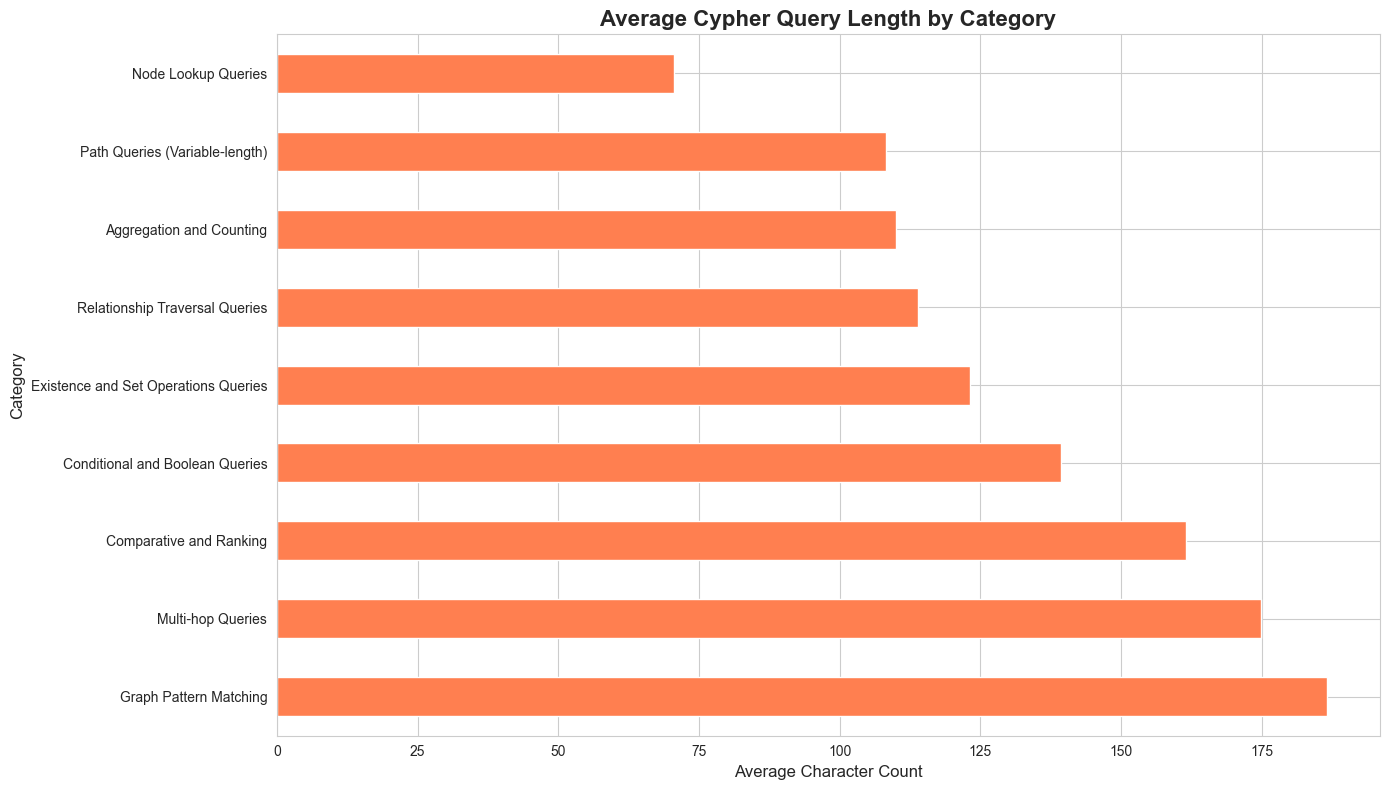

In [9]:
# Visualize average query length by category
plt.figure(figsize=(14, 8))
avg_length = df.groupby('Category')['cypher_length'].mean().sort_values(ascending=False)
avg_length.plot(kind='barh', color='coral')
plt.title('Average Cypher Query Length by Category', fontsize=16, fontweight='bold')
plt.xlabel('Average Character Count', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()


In [10]:
# Create comprehensive summary table
summary = pd.DataFrame({
    'Count': df.groupby('Category').size(),
    'Percentage': (df.groupby('Category').size() / len(df) * 100).round(1),
    'Avg Query Length': df.groupby('Category')['cypher_length'].mean().round(0),
    'Avg MATCH Clauses': df.groupby('Category')['num_match_clauses'].mean().round(2),
    'Avg WHERE Clauses': df.groupby('Category')['num_where_clauses'].mean().round(2),
    'Queries with Aggregation': df.groupby('Category')['has_aggregation'].sum()
})

summary = summary.sort_values('Count', ascending=False)
print("\n" + "=" * 120)
print("COMPREHENSIVE CATEGORY SUMMARY")
print("=" * 120)
summary



COMPREHENSIVE CATEGORY SUMMARY


,Count,Percentage,Avg Query Length,Avg MATCH Clauses,Avg WHERE Clauses,Queries with Aggregation
Category,,,,,,
Node Lookup Queries,173,44.6,71.0,1.00,0.27,14
Relationship Traversal Queries,42,10.8,114.0,1.00,0.12,9
Existence and Set Operations Queries,26,6.7,123.0,1.04,0.81,1
Aggregation and Counting,25,6.4,110.0,1.00,0.00,24
Graph Pattern Matching,25,6.4,187.0,1.00,0.16,1
Multi-hop Queries,25,6.4,175.0,1.00,0.04,1
Path Queries (Variable-length),25,6.4,108.0,1.00,0.04,2
Conditional and Boolean Queries,24,6.2,139.0,1.00,0.88,2
Comparative and Ranking,23,5.9,162.0,1.04,0.22,15
